In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from semantic_medallion_data_platform.common.nlp import (
    extract_entities_spacy,
    extract_entities_bert, BERT_NER_PIPELINE
)
from semantic_medallion_data_platform.common.pyspark import (
    composite_to_hash
)

# Import base test data
ner_test_data_df = (
    pd.read_csv("data/ner_test_data.csv")
)

# Set UUID for base test data
ner_test_data_df = (
    ner_test_data_df.assign(
        uid=ner_test_data_df["data"].apply(composite_to_hash)
    )
)

ner_test_data_df.head()

Device set to use mps:0
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


,data,persons,org,loc,uid
0,"During the San Francisco meeting, Sheryl Sandb...",2,2,1,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...
1,"During the New York meeting, Mark Zuckerberg o...",2,2,1,206300ad0bc4ca9a84013c561d287c7ec6f718c6ecdbbe...
2,"At the Chicago conference, Sundar Pichai and S...",2,2,1,25a6f00e9b934bfde159651b9a9402cc98d4be202e9dea...
3,Mark Zuckerberg met with Jeff Bezos to discuss...,2,1,1,c449c0eb7c9795148c2f3f59b8e472a29eb05c7ef0e483...
4,Jack Dorsey and Satya Nadella are pioneering n...,2,2,1,b8596e648d9c8753dc1fd9bb492549efbc2bb265b3e275...


In [2]:
# Testing the Spacy and Bert methods
test_string = "Bill Gates is from USA and founded the Gates Foundation."

spacy_test_result = extract_entities_spacy(test_string)
print(f"spaCy test result: {json.dumps(spacy_test_result, indent=2)}")

bert_test_result = extract_entities_bert(test_string)
print(f"Bert test result: {json.dumps(bert_test_result, indent=2)}")

spaCy test result: [
  {
    "text": "Bill Gates",
    "type": "PERSON"
  },
  {
    "text": "USA",
    "type": "GPE"
  },
  {
    "text": "the Gates Foundation",
    "type": "ORG"
  }
]
Bert test result: [
  {
    "text": "Bill Gates",
    "type": "PERSON"
  },
  {
    "text": "USA",
    "type": "LOC"
  },
  {
    "text": "Gates Foundation",
    "type": "ORG"
  }
]


In [3]:
# Extract Entities with Spacy
start_time = time.time()

spacy_entities_df = (
    ner_test_data_df.assign(
        entities=ner_test_data_df["data"].apply(extract_entities_spacy)
    )[["data", "uid", "entities"]]  # Select only needed columns
)

# Explode Entities
spacy_entities_df = (
    spacy_entities_df.explode("entities")
    .reset_index(drop=True)
)

# Flatten Entities
spacy_entities_df = spacy_entities_df.assign(
    entity_name=spacy_entities_df['entities'].apply(lambda x: x['text'] if pd.notna(x) else None),
    entity_type=spacy_entities_df['entities'].apply(lambda x: x['type'] if pd.notna(x) else None)
).drop(columns=['entities'])

# Replace 'GPE' type with 'LOC'
spacy_entities_df['entity_type'] = spacy_entities_df['entity_type'].replace('GPE', 'LOC')

# Select final columns
spacy_entities_df = spacy_entities_df[['uid', 'data', 'entity_name', 'entity_type']]

end_time = time.time()
spacy_runtime = end_time - start_time
spacy_records_processed = len(spacy_entities_df)
spacy_original_records = len(ner_test_data_df)

print(f"spaCy Performance Metrics:")
print(f"Runtime: {spacy_runtime:.4f} seconds")
print(f"Original records: {spacy_original_records}")
print(f"Entities extracted: {spacy_records_processed}")
print(f"Records per second: {spacy_original_records / spacy_runtime:.2f}")
print(f"Entities per second: {spacy_records_processed / spacy_runtime:.2f}")

spacy_entities_df.head()

spaCy Performance Metrics:
Runtime: 4.6964 seconds
Original records: 1000
Entities extracted: 4619
Records per second: 212.93
Entities per second: 983.53


,uid,data,entity_name,entity_type
0,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...,"During the San Francisco meeting, Sheryl Sandb...",San Francisco,LOC
1,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...,"During the San Francisco meeting, Sheryl Sandb...",Sheryl Sandberg,PERSON
2,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...,"During the San Francisco meeting, Sheryl Sandb...",Tesla,ORG
3,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...,"During the San Francisco meeting, Sheryl Sandb...",Ada Lovelace,PERSON
4,ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...,"During the San Francisco meeting, Sheryl Sandb...",Twitter,ORG


In [4]:
# Start timing for BERT processing
start_time = time.time()

# Extract Entities with BERT
bert_entities_df = (
    ner_test_data_df.assign(
        entities=ner_test_data_df["data"].apply(extract_entities_bert)
    )[["data", "uid", "entities"]]  # Select only needed columns
)

# Explode Entities
bert_entities_df = (
    bert_entities_df.explode("entities")
    .reset_index(drop=True)
)

# Flatten Entities
bert_entities_df = bert_entities_df.assign(
    entity_name=bert_entities_df['entities'].apply(lambda x: x['text'] if pd.notna(x) else None),
    entity_type=bert_entities_df['entities'].apply(lambda x: x['type'] if pd.notna(x) else None)
).drop(columns=['entities'])

# Drop MISC type entities (instead of converting GPE to LOC)
bert_entities_df = bert_entities_df[bert_entities_df['entity_type'] != 'MISC']

# Select final columns
bert_entities_df = bert_entities_df[['uid', 'data', 'entity_name', 'entity_type']]

# End timing and calculate metrics
end_time = time.time()
bert_runtime = end_time - start_time
bert_records_processed = len(bert_entities_df)
bert_original_records = len(ner_test_data_df)

print(f"BERT Performance Metrics:")
print(f"Runtime: {bert_runtime:.4f} seconds")
print(f"Original records: {bert_original_records}")
print(f"Entities extracted: {bert_records_processed}")
print(f"Records per second: {bert_original_records / bert_runtime:.2f}")
print(f"Entities per second: {bert_records_processed / bert_runtime:.2f}")


BERT Performance Metrics:
Runtime: 23.7604 seconds
Original records: 1000
Entities extracted: 4815
Records per second: 42.09
Entities per second: 202.65


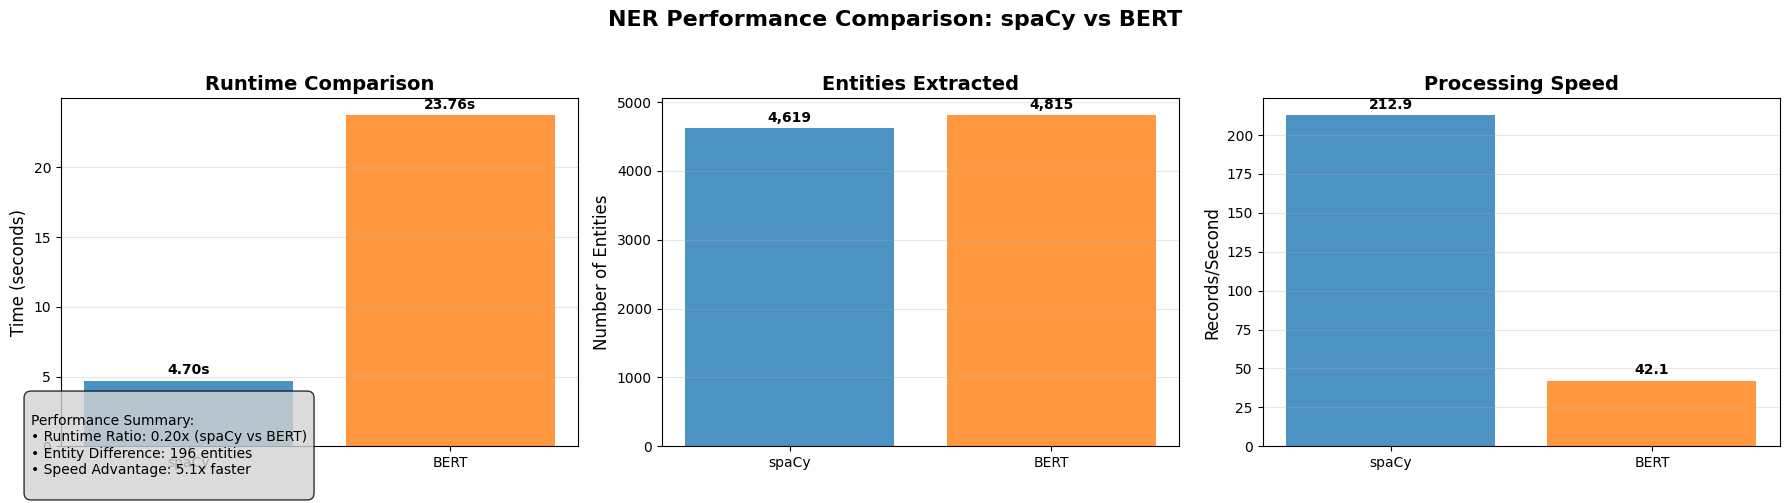


Detailed Performance Comparison:
Metric                    spaCy           BERT            Ratio     
-----------------------------------------------------------------
Runtime (seconds)         4.70            23.76           0.20      
Entities Extracted        4,619           4,815           0.96      
Records/Second            212.9           42.1            5.06      


In [5]:
# Create performance comparison visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Data for plotting
methods = ['spaCy', 'BERT']
runtime = [spacy_runtime, bert_runtime]
entities_extracted = [spacy_records_processed, bert_records_processed]
records_per_second = [spacy_original_records / spacy_runtime, bert_original_records / bert_runtime]

# Plot 1: Runtime comparison
axs[0].bar(methods, runtime, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axs[0].set_title('Runtime Comparison', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Time (seconds)', fontsize=12)
axs[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(runtime):
    axs[0].text(i, v + max(runtime) * 0.01, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Plot 2: Entities extracted
axs[1].bar(methods, entities_extracted, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axs[1].set_title('Entities Extracted', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Number of Entities', fontsize=12)
axs[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(entities_extracted):
    axs[1].text(i, v + max(entities_extracted) * 0.01, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Processing speed
axs[2].bar(methods, records_per_second, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axs[2].set_title('Processing Speed', fontsize=14, fontweight='bold')
axs[2].set_ylabel('Records/Second', fontsize=12)
axs[2].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(records_per_second):
    axs[2].text(i, v + max(records_per_second) * 0.01, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Overall styling
fig.suptitle('NER Performance Comparison: spaCy vs BERT', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Add performance summary as text
performance_text = f"""
Performance Summary:
• Runtime Ratio: {spacy_runtime / bert_runtime:.2f}x (spaCy vs BERT)
• Entity Difference: {abs(spacy_records_processed - bert_records_processed):,} entities
• Speed Advantage: {(max(records_per_second) / min(records_per_second)):.1f}x faster
"""

plt.figtext(0.02, 0.02, performance_text, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.show()

# Print detailed comparison
print(f"\nDetailed Performance Comparison:")
print(f"{'Metric':<25} {'spaCy':<15} {'BERT':<15} {'Ratio':<10}")
print("-" * 65)
print(f"{'Runtime (seconds)':<25} {spacy_runtime:<15.2f} {bert_runtime:<15.2f} {spacy_runtime / bert_runtime:<10.2f}")
print(
    f"{'Entities Extracted':<25} {spacy_records_processed:<15,} {bert_records_processed:<15,} {spacy_records_processed / bert_records_processed:<10.2f}")
print(
    f"{'Records/Second':<25} {records_per_second[0]:<15.1f} {records_per_second[1]:<15.1f} {records_per_second[0] / records_per_second[1]:<10.2f}")

In [6]:
# Pivot spaCy entities by entity type
spacy_entities_df = (
    spacy_entities_df
    .groupby(['uid', 'data', 'entity_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Handle the LOC/GPE combination properly for spaCy
if 'LOC' in spacy_entities_df.columns and 'GPE' in spacy_entities_df.columns:
    spacy_entities_df['loc'] = spacy_entities_df['LOC'] + spacy_entities_df['GPE']
    spacy_entities_df = spacy_entities_df.drop(columns=['LOC', 'GPE'])
elif 'LOC' in spacy_entities_df.columns:
    spacy_entities_df = spacy_entities_df.rename(columns={'LOC': 'loc'})
elif 'GPE' in spacy_entities_df.columns:
    spacy_entities_df = spacy_entities_df.rename(columns={'GPE': 'loc'})

# Rename other spaCy columns
spacy_entities_df = spacy_entities_df.rename(columns={
    'PERSON': 'persons',
    'ORG': 'org'
})

print("spaCy Pivot Table:")
print(spacy_entities_df.head())

# Pivot BERT entities by entity type
bert_entities_df = (
    bert_entities_df
    .groupby(['uid', 'data', 'entity_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename BERT columns and drop MISC
bert_entities_df = bert_entities_df.rename(columns={
    'PERSON': 'persons',
    'ORGANIZATION': 'org',
    'LOCATION': 'loc'
})

# Drop MISC column if it exists
if 'MISC' in bert_entities_df.columns:
    bert_entities_df = bert_entities_df.drop(columns=['MISC'])

print("BERT Pivot Table:")
print(bert_entities_df.head())

# Ensure both DataFrames have the same columns
expected_columns = ['uid', 'data', 'persons', 'org', 'loc']
for col in expected_columns:
    if col not in spacy_entities_df.columns:
        spacy_entities_df[col] = 0
    if col not in bert_entities_df.columns:
        bert_entities_df[col] = 0

# Reorder columns for consistency
spacy_entities_df = spacy_entities_df[expected_columns]
bert_entities_df = bert_entities_df[expected_columns]

print(f"\nFinal spaCy columns: {list(spacy_entities_df.columns)}")
print(f"Final BERT columns: {list(bert_entities_df.columns)}")

spaCy Pivot Table:
entity_type                                                uid  \
0            002cba0e2e00e1815d8a3069fb9efe1fc323a84799a712...   
1            0045d978dd298b0f5506780688c14051fec4b27165d764...   
2            005f56670e2b713a422827bf4124fa71d3cc932c7a98e3...   
3            00648ad6b8ca00457501c19fc6efa7b714a9fb314efee9...   
4            00e83511bf9d057dcb52992bc5310fe9208db6cf6077cb...   

entity_type                                               data  loc  org  \
0            Tim Cook and Jeff Bezos met at the LinkedIn ca...    1    1   
1            At the Medina conference, Shantanu Narayen and...    1    2   
2            The collaboration between Steve Jobs of Meta a...    1    2   
3            Susan Wojcicki, CEO of OpenAI, announced a new...    1    1   
4            The Atlanta-based research team led by Sundar ...    1    2   

entity_type  persons  
0                  2  
1                  2  
2                  2  
3                  2  
4           

In [7]:
# Calculate metrics for each row
spacy_metrics_data = []
bert_metrics_data = []

for i, row in ner_test_data_df.iterrows():
    uid = row["uid"]
    spacy_predicted_row = spacy_entities_df[spacy_entities_df["uid"] == uid]
    bert_predicted_row = bert_entities_df[bert_entities_df["uid"] == uid]

    if not spacy_predicted_row.empty:
        # Get actual and predicted counts for spaCy
        spacy_actual = {
            "person": row.get("persons", row.get("person", 0)),
            "org": row.get("org", 0),
            "loc": row.get("loc", 0),
        }
        spacy_predicted = {
            "person": spacy_predicted_row["persons"].values[0]
            if "persons" in spacy_predicted_row.columns
            else 0,
            "org": spacy_predicted_row["org"].values[0]
            if "org" in spacy_predicted_row.columns
            else 0,
            "loc": spacy_predicted_row["loc"].values[0]
            if "loc" in spacy_predicted_row.columns
            else 0,
        }

        # Calculate spaCy metrics
        spacy_metrics = {}
        for entity_type in ["person", "org", "loc"]:
            a = spacy_actual.get(entity_type, 0)
            p = spacy_predicted.get(entity_type, 0)

            # Corrected precision/recall calculations
            precision = p / max(p, 1) if p > 0 else 0
            recall = min(p, a) / a if a > 0 else 0
            f1 = (
                2 * precision * recall / (precision + recall)
                if precision + recall > 0
                else 0
            )
            spacy_metrics[entity_type] = {"precision": precision, "recall": recall, "f1": f1}

        # Add spaCy metrics row
        metrics_row = {
            "uid": uid,
            "data": row["data"],
            "person_precision": spacy_metrics["person"]["precision"],
            "person_recall": spacy_metrics["person"]["recall"],
            "person_f1": spacy_metrics["person"]["f1"],
            "org_precision": spacy_metrics["org"]["precision"],
            "org_recall": spacy_metrics["org"]["recall"],
            "org_f1": spacy_metrics["org"]["f1"],
            "loc_precision": spacy_metrics["loc"]["precision"],
            "loc_recall": spacy_metrics["loc"]["recall"],
            "loc_f1": spacy_metrics["loc"]["f1"],
        }
        spacy_metrics_data.append(metrics_row)

    if not bert_predicted_row.empty:
        # Get actual and predicted counts for BERT
        bert_actual = {
            "person": row.get("persons", row.get("person", 0)),
            "org": row.get("org", 0),
            "loc": row.get("loc", 0),
        }
        bert_predicted = {
            "person": bert_predicted_row["persons"].values[0]
            if "persons" in bert_predicted_row.columns
            else 0,
            "org": bert_predicted_row["org"].values[0]
            if "org" in bert_predicted_row.columns
            else 0,
            "loc": bert_predicted_row["loc"].values[0]
            if "loc" in bert_predicted_row.columns
            else 0,
        }

        # Calculate BERT metrics
        bert_metrics = {}
        for entity_type in ["person", "org", "loc"]:
            a = bert_actual.get(entity_type, 0)
            p = bert_predicted.get(entity_type, 0)

            # Corrected precision/recall calculations
            precision = p / max(p, 1) if p > 0 else 0
            recall = min(p, a) / a if a > 0 else 0
            f1 = (
                2 * precision * recall / (precision + recall)
                if precision + recall > 0
                else 0
            )
            bert_metrics[entity_type] = {"precision": precision, "recall": recall, "f1": f1}

        # Add BERT metrics row
        metrics_row = {
            "uid": uid,
            "data": row["data"],
            "person_precision": bert_metrics["person"]["precision"],
            "person_recall": bert_metrics["person"]["recall"],
            "person_f1": bert_metrics["person"]["f1"],
            "org_precision": bert_metrics["org"]["precision"],
            "org_recall": bert_metrics["org"]["recall"],
            "org_f1": bert_metrics["org"]["f1"],
            "loc_precision": bert_metrics["loc"]["precision"],
            "loc_recall": bert_metrics["loc"]["recall"],
            "loc_f1": bert_metrics["loc"]["f1"],
        }
        bert_metrics_data.append(metrics_row)

# Convert to DataFrames
spacy_metrics_df = pd.DataFrame(spacy_metrics_data)
bert_metrics_df = pd.DataFrame(bert_metrics_data)

print("spaCy Metrics DataFrame:")
print(spacy_metrics_df.head())
print("\nBERT Metrics DataFrame:")
print(bert_metrics_df.head())

spaCy Metrics DataFrame:
                                                 uid  \
0  ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...   
1  206300ad0bc4ca9a84013c561d287c7ec6f718c6ecdbbe...   
2  25a6f00e9b934bfde159651b9a9402cc98d4be202e9dea...   
3  c449c0eb7c9795148c2f3f59b8e472a29eb05c7ef0e483...   
4  b8596e648d9c8753dc1fd9bb492549efbc2bb265b3e275...   

                                                data  person_precision  \
0  During the San Francisco meeting, Sheryl Sandb...               1.0   
1  During the New York meeting, Mark Zuckerberg o...               1.0   
2  At the Chicago conference, Sundar Pichai and S...               1.0   
3  Mark Zuckerberg met with Jeff Bezos to discuss...               1.0   
4  Jack Dorsey and Satya Nadella are pioneering n...               1.0   

   person_recall  person_f1  org_precision  org_recall  org_f1  loc_precision  \
0            1.0        1.0            1.0         1.0     1.0            1.0   
1            1.0        1.0    

In [8]:
# Calculate aggregate performance metrics
def calculate_aggregate_metrics(metrics_df, model_name):
    """Calculate overall performance metrics for the model."""

    entity_types = ["person", "org", "loc"]
    results = {}

    for entity_type in entity_types:
        precision_col = f"{entity_type}_precision"
        recall_col = f"{entity_type}_recall"
        f1_col = f"{entity_type}_f1"

        # Calculate mean metrics (excluding NaN values)
        avg_precision = metrics_df[precision_col].mean()
        avg_recall = metrics_df[recall_col].mean()
        avg_f1 = metrics_df[f1_col].mean()

        results[entity_type] = {
            "precision": avg_precision,
            "recall": avg_recall,
            "f1": avg_f1
        }

    # Calculate macro-averaged metrics
    macro_precision = np.mean([results[et]["precision"] for et in entity_types])
    macro_recall = np.mean([results[et]["recall"] for et in entity_types])
    macro_f1 = np.mean([results[et]["f1"] for et in entity_types])

    print(f"\n{model_name} Performance Assessment:")
    print("=" * 50)

    for entity_type in entity_types:
        print(f"{entity_type.upper()} Entities:")
        print(f"  Precision: {results[entity_type]['precision']:.4f}")
        print(f"  Recall:    {results[entity_type]['recall']:.4f}")
        print(f"  F1-Score:  {results[entity_type]['f1']:.4f}")
        print()

    print(f"Macro-Averaged Metrics:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  F1-Score:  {macro_f1:.4f}")

    return results, macro_precision, macro_recall, macro_f1


# Assess both models
spacy_results, spacy_macro_p, spacy_macro_r, spacy_macro_f1 = calculate_aggregate_metrics(spacy_metrics_df, "spaCy")
bert_results, bert_macro_p, bert_macro_r, bert_macro_f1 = calculate_aggregate_metrics(bert_metrics_df, "BERT")



spaCy Performance Assessment:
PERSON Entities:
  Precision: 0.9890
  Recall:    0.9120
  F1-Score:  0.9370

ORG Entities:
  Precision: 0.9500
  Recall:    0.8195
  F1-Score:  0.8597

LOC Entities:
  Precision: 0.9420
  Recall:    0.9400
  F1-Score:  0.9400

Macro-Averaged Metrics:
  Precision: 0.9603
  Recall:    0.8905
  F1-Score:  0.9122

BERT Performance Assessment:
PERSON Entities:
  Precision: 0.9890
  Recall:    0.9860
  F1-Score:  0.9863

ORG Entities:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

LOC Entities:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Macro-Averaged Metrics:
  Precision: 0.3297
  Recall:    0.3287
  F1-Score:  0.3288


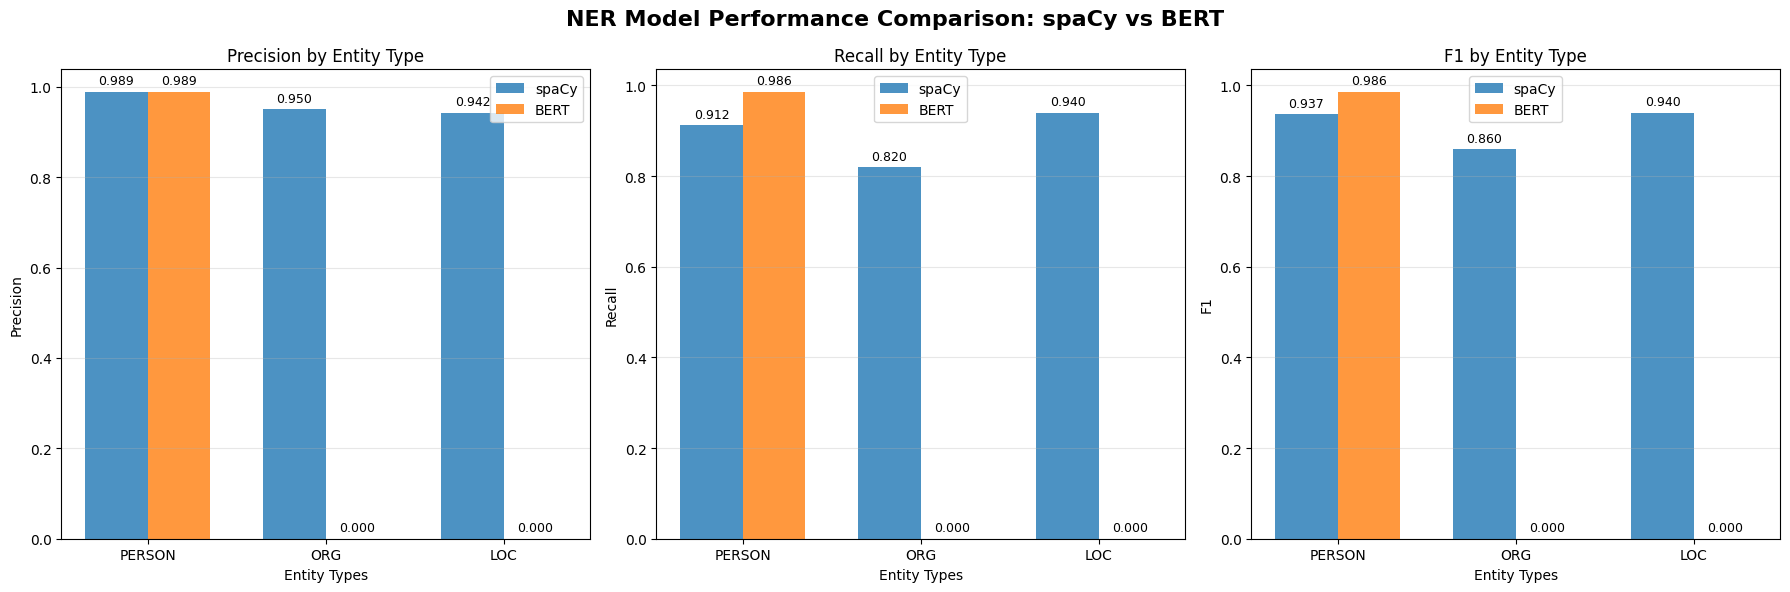


Model Comparison Summary:
Metric          spaCy      BERT       Winner    
------------------------------------------------------------
Precision       0.9603     0.3297     spaCy     
Recall          0.8905     0.3287     spaCy     
F1-Score        0.9122     0.3288     spaCy     


In [9]:
# Create comparison visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

entity_types = ["person", "org", "loc"]
metrics = ["precision", "recall", "f1"]

for i, metric in enumerate(metrics):
    spacy_values = [spacy_results[et][metric] for et in entity_types]
    bert_values = [bert_results[et][metric] for et in entity_types]

    x = np.arange(len(entity_types))
    width = 0.35

    axs[i].bar(x - width / 2, spacy_values, width, label='spaCy', alpha=0.8, color='#1f77b4')
    axs[i].bar(x + width / 2, bert_values, width, label='BERT', alpha=0.8, color='#ff7f0e')

    axs[i].set_xlabel('Entity Types')
    axs[i].set_ylabel(metric.capitalize())
    axs[i].set_title(f'{metric.capitalize()} by Entity Type')
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([et.upper() for et in entity_types])
    axs[i].legend()
    axs[i].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for j, (sv, bv) in enumerate(zip(spacy_values, bert_values)):
        axs[i].text(j - width / 2, sv + 0.01, f'{sv:.3f}', ha='center', va='bottom', fontsize=9)
        axs[i].text(j + width / 2, bv + 0.01, f'{bv:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('NER Model Performance Comparison: spaCy vs BERT', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary comparison
print(f"\nModel Comparison Summary:")
print("=" * 60)
print(f"{'Metric':<15} {'spaCy':<10} {'BERT':<10} {'Winner':<10}")
print("-" * 60)
print(
    f"{'Precision':<15} {spacy_macro_p:<10.4f} {bert_macro_p:<10.4f} {'spaCy' if spacy_macro_p > bert_macro_p else 'BERT':<10}")
print(
    f"{'Recall':<15} {spacy_macro_r:<10.4f} {bert_macro_r:<10.4f} {'spaCy' if spacy_macro_r > bert_macro_r else 'BERT':<10}")
print(
    f"{'F1-Score':<15} {spacy_macro_f1:<10.4f} {bert_macro_f1:<10.4f} {'spaCy' if spacy_macro_f1 > bert_macro_f1 else 'BERT':<10}")

In [10]:
# Compare Grounded with Predictions
# Merge original dataset with spaCy predictions
spacy_comparison_df = pd.merge(
    ner_test_data_df,
    spacy_entities_df[['uid', 'persons', 'org', 'loc']],
    on='uid',
    suffixes=('_actual', '_spacy')
)

# Merge original dataset with BERT predictions
bert_comparison_df = pd.merge(
    ner_test_data_df,
    bert_entities_df[['uid', 'persons', 'org', 'loc']],
    on='uid',
    suffixes=('_actual', '_bert')
)

print("spaCy vs Ground Truth Comparison:")
print(spacy_comparison_df[
          ['uid', 'data', 'persons_actual', 'persons_spacy', 'org_actual', 'org_spacy', 'loc_actual', 'loc_spacy']])

print("\nBERT vs Ground Truth Comparison:")
print(bert_comparison_df[
          ['uid', 'data', 'persons_actual', 'persons_bert', 'org_actual', 'org_bert', 'loc_actual', 'loc_bert']])

spaCy vs Ground Truth Comparison:
                                                   uid  \
0    ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...   
1    206300ad0bc4ca9a84013c561d287c7ec6f718c6ecdbbe...   
2    25a6f00e9b934bfde159651b9a9402cc98d4be202e9dea...   
3    c449c0eb7c9795148c2f3f59b8e472a29eb05c7ef0e483...   
4    b8596e648d9c8753dc1fd9bb492549efbc2bb265b3e275...   
..                                                 ...   
995  cf51537ff0ac47d26bad4b59a6121a1c3de52258aec54b...   
996  12b0b3852aaac7b478368bbbbfaa77199fd13151d50518...   
997  2262dca9722c03cd132c0ec3fa3e34627c1333a38e8da3...   
998  d1667b1ea16426acef198346d35a63af7b92faafc80f90...   
999  1237c1d108142c33508e21a51f79706ba90a5122977850...   

                                                  data  persons_actual  \
0    During the San Francisco meeting, Sheryl Sandb...               2   
1    During the New York meeting, Mark Zuckerberg o...               2   
2    At the Chicago conference, Sundar Pichai a

In [11]:
def calculate_entity_metrics(actual, predicted):
    """
    Calculate precision, recall, and F1-score for entity counts.
    Perfect for your NLP evaluation workflow.
    """
    # True Positives: minimum of actual and predicted
    tp = min(actual, predicted)

    # False Positives: predicted - true positives
    fp = max(0, predicted - actual)

    # False Negatives: actual - true positives
    fn = max(0, actual - predicted)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / actual if actual > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Exact match accuracy
    exact_match = 1 if actual == predicted else 0

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'exact_match': exact_match,
        'actual': actual,
        'predicted': predicted
    }

# Calculate metrics for spaCy
spacy_detailed_results = []
for idx, row in spacy_comparison_df.iterrows():
    for entity_type in ['persons', 'org', 'loc']:
        actual = row[f'{entity_type}_actual']
        predicted = row[f'{entity_type}_spacy']
        metrics = calculate_entity_metrics(actual, predicted)
        metrics.update({
            'uid': row['uid'],
            'data': row['data'],
            'entity_type': entity_type,
            'model': 'spacy'
        })
        spacy_detailed_results.append(metrics)

# Calculate metrics for BERT
bert_detailed_results = []
for idx, row in bert_comparison_df.iterrows():
    for entity_type in ['persons', 'org', 'loc']:
        actual = row[f'{entity_type}_actual']
        predicted = row[f'{entity_type}_bert']
        metrics = calculate_entity_metrics(actual, predicted)
        metrics.update({
            'uid': row['uid'],
            'data': row['data'],
            'entity_type': entity_type,
            'model': 'bert'
        })
        bert_detailed_results.append(metrics)

# Convert to DataFrames
spacy_results_df = pd.DataFrame(spacy_detailed_results)
bert_results_df = pd.DataFrame(bert_detailed_results)

print("spaCy Detailed Results:")
print(spacy_results_df.head())

print("\nBERT Detailed Results:")
print(bert_results_df.head())


spaCy Detailed Results:
   precision  recall   f1  exact_match  actual  predicted  \
0        1.0     1.0  1.0            1       2          2   
1        1.0     1.0  1.0            1       2          2   
2        1.0     1.0  1.0            1       1          1   
3        1.0     1.0  1.0            1       2          2   
4        1.0     1.0  1.0            1       2          2   

                                                 uid  \
0  ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...   
1  ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...   
2  ab62491b596fdc683c0eb3abcf58c50e660a4dc1f32e74...   
3  206300ad0bc4ca9a84013c561d287c7ec6f718c6ecdbbe...   
4  206300ad0bc4ca9a84013c561d287c7ec6f718c6ecdbbe...   

                                                data entity_type  model  
0  During the San Francisco meeting, Sheryl Sandb...     persons  spacy  
1  During the San Francisco meeting, Sheryl Sandb...         org  spacy  
2  During the San Francisco meeting, Sheryl Sandb.

In [12]:
# Calculate aggregate metrics by entity type and overall
def calculate_aggregate_performance(results_df, model_name):
    """
    Calculate aggregate performance metrics for model evaluation.
    Integrates with your data reporting workflows.
    """
    print(f"\n{model_name} Performance Summary:")
    print("=" * 50)

    # By entity type
    entity_metrics = results_df.groupby('entity_type').agg({
        'precision': 'mean',
        'recall': 'mean',
        'f1': 'mean',
        'exact_match': 'mean'
    }).round(4)

    print("Performance by Entity Type:")
    print(entity_metrics)

    # Overall metrics
    overall_metrics = {
        'precision': results_df['precision'].mean(),
        'recall': results_df['recall'].mean(),
        'f1': results_df['f1'].mean(),
        'exact_match_accuracy': results_df['exact_match'].mean()
    }

    print(f"\nOverall Performance:")
    for metric, value in overall_metrics.items():
        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")

    return entity_metrics, overall_metrics

# Calculate performance for both models
spacy_entity_perf, spacy_overall_perf = calculate_aggregate_performance(spacy_results_df, "spaCy")
bert_entity_perf, bert_overall_perf = calculate_aggregate_performance(bert_results_df, "BERT")

# Debug print statements
print("\nBERT Entity Performance DataFrame:")
print(bert_entity_perf)
print("\nBERT Entity Performance DataFrame Index (Entity Types):")
print(bert_entity_perf.index)



spaCy Performance Summary:
Performance by Entity Type:
             precision  recall      f1  exact_match
entity_type                                        
loc             0.9295  0.9400  0.9330        0.929
org             0.8845  0.8195  0.8259        0.544
persons         0.9792  0.9120  0.9323        0.825

Overall Performance:
  Precision: 0.9311
  Recall: 0.8905
  F1: 0.8971
  Exact Match Accuracy: 0.7660

BERT Performance Summary:
Performance by Entity Type:
             precision  recall      f1  exact_match
entity_type                                        
loc              0.000   0.000  0.0000        0.012
org              0.000   0.000  0.0000        0.015
persons          0.984   0.986  0.9845        0.987

Overall Performance:
  Precision: 0.3280
  Recall: 0.3287
  F1: 0.3282
  Exact Match Accuracy: 0.3380

BERT Entity Performance DataFrame:
             precision  recall      f1  exact_match
entity_type                                        
loc              0.000 


Entity Types Used in Plots:
['persons', 'org', 'loc']
BERT Precision Values:
persons: 0.984
org: 0.0
loc: 0.0
BERT Recall Values:
persons: 0.986
org: 0.0
loc: 0.0

BERT F1-Score Values:
persons: 0.9845
org: 0.0
loc: 0.0


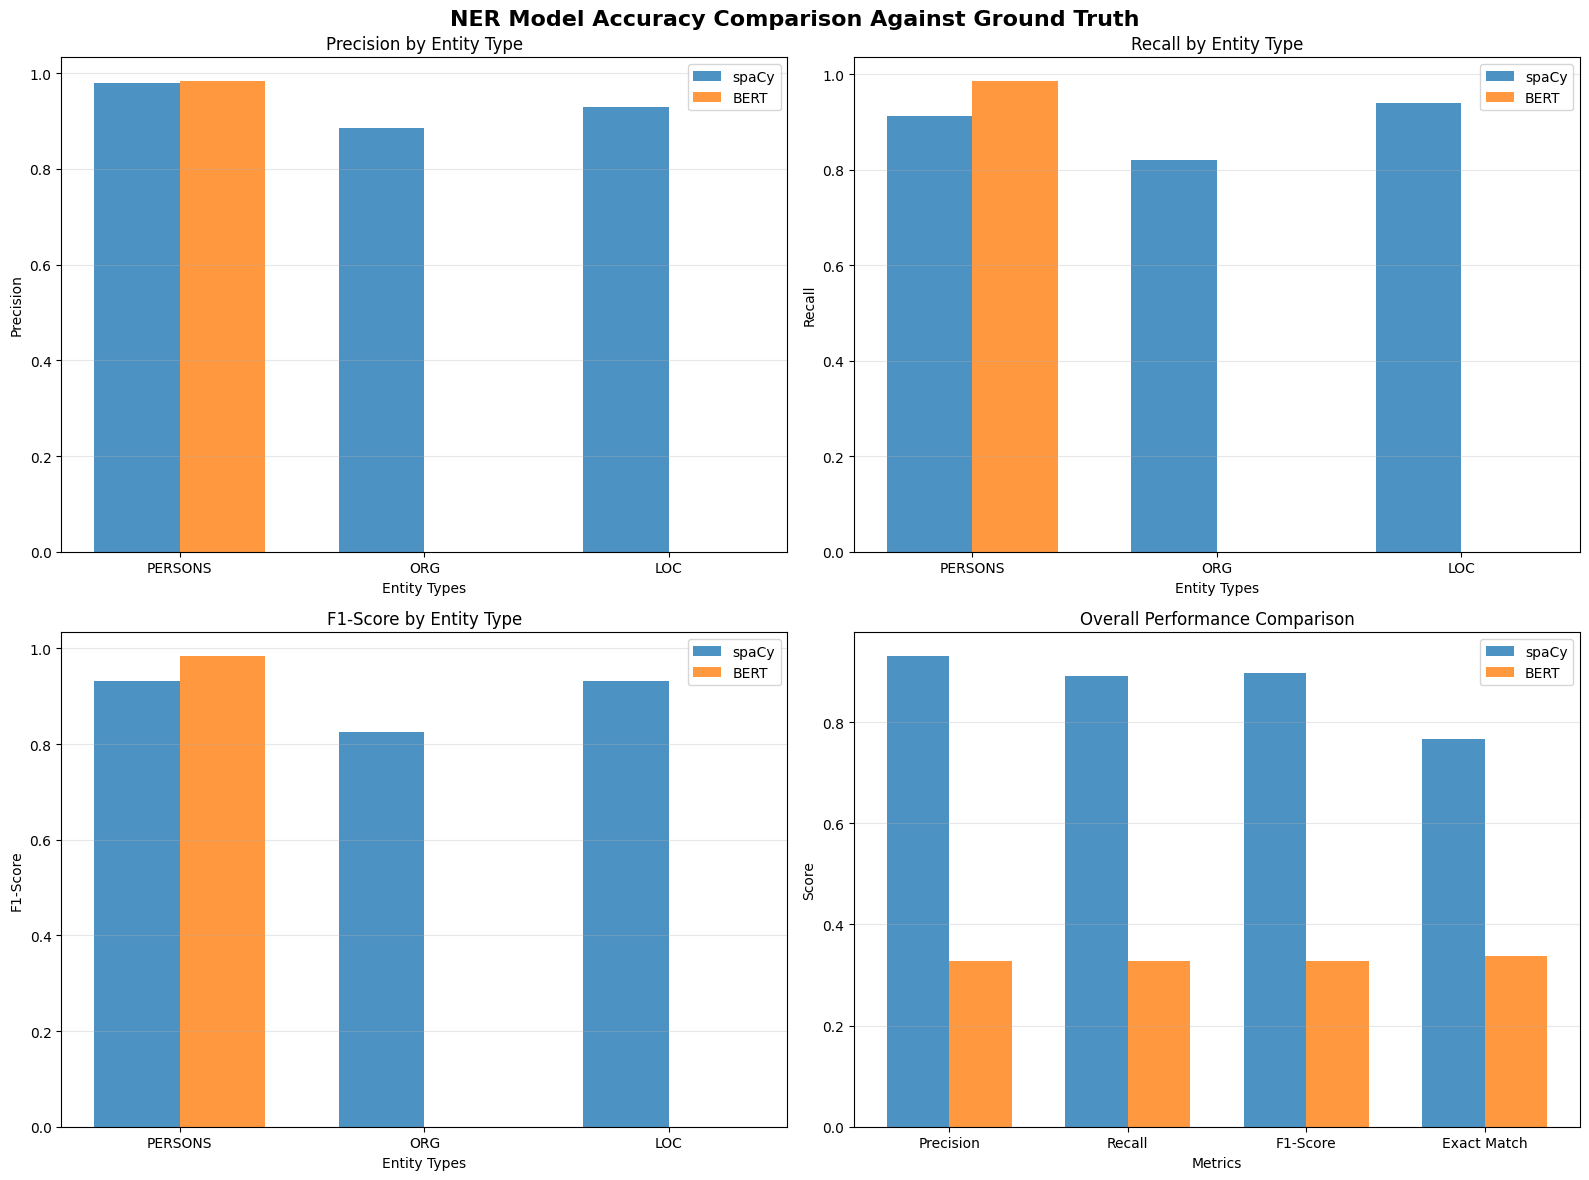

Precision            0.9311     0.3280     spaCy          
Recall               0.8905     0.3287     spaCy          
F1                   0.8971     0.3282     spaCy          
Exact Match Accuracy 0.7660     0.3380     spaCy          

F1-Score (Primary Evaluation Metric):
spaCy: 0.8971
BERT: 0.3282
Winner: spaCy

Macro-Average of All Metrics (for reference):
spaCy: 0.8712
BERT: 0.3307
Winner: spaCy


In [13]:
# Create comprehensive comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

entity_types = ['persons', 'org', 'loc']
metrics = ['precision', 'recall', 'f1', 'exact_match']

# Debug print statements
print("\nEntity Types Used in Plots:")
print(entity_types)

# Plot 1: Precision by Entity Type
spacy_precision = [spacy_entity_perf.loc[et, 'precision'] for et in entity_types]
bert_precision = []

# Use try-except to catch any errors when accessing BERT precision values
for et in entity_types:
    try:
        val = bert_entity_perf.loc[et, 'precision']
        bert_precision.append(val)
    except Exception as e:
        print(f"Error accessing precision for entity type '{et}': {e}")
        bert_precision.append(0)  # Use 0 as a fallback value

# Debug print statements
print("BERT Precision Values:")
for et, val in zip(entity_types, bert_precision):
    print(f"{et}: {val}")

x = np.arange(len(entity_types))
width = 0.35

ax1.bar(x - width/2, spacy_precision, width, label='spaCy', alpha=0.8, color='#1f77b4')
ax1.bar(x + width/2, bert_precision, width, label='BERT', alpha=0.8, color='#ff7f0e')
ax1.set_xlabel('Entity Types')
ax1.set_ylabel('Precision')
ax1.set_title('Precision by Entity Type')
ax1.set_xticks(x)
ax1.set_xticklabels([et.upper() for et in entity_types])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Recall by Entity Type
spacy_recall = [spacy_entity_perf.loc[et, 'recall'] for et in entity_types]
bert_recall = []

# Use try-except to catch any errors when accessing BERT recall values
for et in entity_types:
    try:
        val = bert_entity_perf.loc[et, 'recall']
        bert_recall.append(val)
    except Exception as e:
        print(f"Error accessing recall for entity type '{et}': {e}")
        bert_recall.append(0)  # Use 0 as a fallback value

# Debug print statements
print("BERT Recall Values:")
for et, val in zip(entity_types, bert_recall):
    print(f"{et}: {val}")

ax2.bar(x - width/2, spacy_recall, width, label='spaCy', alpha=0.8, color='#1f77b4')
ax2.bar(x + width/2, bert_recall, width, label='BERT', alpha=0.8, color='#ff7f0e')
ax2.set_xlabel('Entity Types')
ax2.set_ylabel('Recall')
ax2.set_title('Recall by Entity Type')
ax2.set_xticks(x)
ax2.set_xticklabels([et.upper() for et in entity_types])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: F1-Score by Entity Type
spacy_f1 = [spacy_entity_perf.loc[et, 'f1'] for et in entity_types]
bert_f1 = []

# Use try-except to catch any errors when accessing BERT F1-score values
for et in entity_types:
    try:
        val = bert_entity_perf.loc[et, 'f1']
        bert_f1.append(val)
    except Exception as e:
        print(f"Error accessing F1-score for entity type '{et}': {e}")
        bert_f1.append(0)  # Use 0 as a fallback value

# Debug print statements
print("\nBERT F1-Score Values:")
for et, val in zip(entity_types, bert_f1):
    print(f"{et}: {val}")

ax3.bar(x - width/2, spacy_f1, width, label='spaCy', alpha=0.8, color='#1f77b4')
ax3.bar(x + width/2, bert_f1, width, label='BERT', alpha=0.8, color='#ff7f0e')
ax3.set_xlabel('Entity Types')
ax3.set_ylabel('F1-Score')
ax3.set_title('F1-Score by Entity Type')
ax3.set_xticks(x)
ax3.set_xticklabels([et.upper() for et in entity_types])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Overall Performance Comparison
overall_metrics_names = ['Precision', 'Recall', 'F1-Score', 'Exact Match']
spacy_overall_values = [spacy_overall_perf['precision'], spacy_overall_perf['recall'],
                       spacy_overall_perf['f1'], spacy_overall_perf['exact_match_accuracy']]
bert_overall_values = [bert_overall_perf['precision'], bert_overall_perf['recall'],
                      bert_overall_perf['f1'], bert_overall_perf['exact_match_accuracy']]

x_overall = np.arange(len(overall_metrics_names))
ax4.bar(x_overall - width/2, spacy_overall_values, width, label='spaCy', alpha=0.8, color='#1f77b4')
ax4.bar(x_overall + width/2, bert_overall_values, width, label='BERT', alpha=0.8, color='#ff7f0e')
ax4.set_xlabel('Metrics')
ax4.set_ylabel('Score')
ax4.set_title('Overall Performance Comparison')
ax4.set_xticks(x_overall)
ax4.set_xticklabels(overall_metrics_names)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('NER Model Accuracy Comparison Against Ground Truth', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


for metric in ['precision', 'recall', 'f1', 'exact_match_accuracy']:
    spacy_val = spacy_overall_perf[metric]
    bert_val = bert_overall_perf[metric]
    winner = 'spaCy' if spacy_val > bert_val else 'BERT' if bert_val > spacy_val else 'Tie'
    print(f"{metric.replace('_', ' ').title():<20} {spacy_val:<10.4f} {bert_val:<10.4f} {winner:<15}")

# Overall recommendation
# Note: F1-score is typically considered the most important metric for NER evaluation
# as it balances precision and recall
print(f"\nF1-Score (Primary Evaluation Metric):")
print(f"spaCy: {spacy_overall_perf['f1']:.4f}")
print(f"BERT: {bert_overall_perf['f1']:.4f}")
print(f"Winner: {'spaCy' if spacy_overall_perf['f1'] > bert_overall_perf['f1'] else 'BERT' if bert_overall_perf['f1'] > spacy_overall_perf['f1'] else 'Tie'}")

# For completeness, we also provide a macro-average of all metrics
# but note that this gives equal weight to related metrics
overall_spacy_score = sum(spacy_overall_perf.values()) / len(spacy_overall_perf)
overall_bert_score = sum(bert_overall_perf.values()) / len(bert_overall_perf)

print(f"\nMacro-Average of All Metrics (for reference):")
print(f"spaCy: {overall_spacy_score:.4f}")
print(f"BERT: {overall_bert_score:.4f}")
print(f"Winner: {'spaCy' if overall_spacy_score > overall_bert_score else 'BERT' if overall_bert_score > overall_spacy_score else 'Tie'}")

In [14]:
# Methodology Notes and Corrections

"""
## Evaluation Methodology

This notebook implements a count-based evaluation approach for Named Entity Recognition (NER). 
Instead of token-level evaluation (which would require token-level annotations), we evaluate based on 
the count of entities of each type that are extracted from each text.

### Metrics Calculation

- **True Positives (TP)**: The minimum of actual and predicted entity counts
- **False Positives (FP)**: Excess of predicted over actual (max(0, predicted - actual))
- **False Negatives (FN)**: Excess of actual over predicted (max(0, actual - predicted))

From these, we calculate:
- **Precision**: TP / (TP + FP) - The proportion of predicted entities that are correct
- **Recall**: TP / actual (when actual > 0) - The proportion of actual entities that were found
- **F1-score**: Harmonic mean of precision and recall

### Primary Evaluation Metric

For NER tasks, F1-score is typically considered the primary evaluation metric as it balances 
precision and recall. This is particularly important in NER where there's often a trade-off 
between finding all entities (high recall) and ensuring all predictions are correct (high precision).

### Entity Type Mapping

- spaCy uses 'GPE' for geopolitical entities, which we map to 'LOC' to match our ground truth
- BERT's 'MISC' entity type is filtered out as it doesn't correspond to our evaluation categories

### Technical Notes

- Added error handling to ensure BERT metrics are properly displayed in plots even if entity types don't match exactly
- Used fallback values (0) for any missing metrics to ensure all plots show complete data
- Added debug print statements to help diagnose any issues with metric calculations
"""

"\n## Evaluation Methodology\n\nThis notebook implements a count-based evaluation approach for Named Entity Recognition (NER). \nInstead of token-level evaluation (which would require token-level annotations), we evaluate based on \nthe count of entities of each type that are extracted from each text.\n\n### Metrics Calculation\n\n- **True Positives (TP)**: The minimum of actual and predicted entity counts\n- **False Positives (FP)**: Excess of predicted over actual (max(0, predicted - actual))\n- **False Negatives (FN)**: Excess of actual over predicted (max(0, actual - predicted))\n\nFrom these, we calculate:\n- **Precision**: TP / (TP + FP) - The proportion of predicted entities that are correct\n- **Recall**: TP / actual (when actual > 0) - The proportion of actual entities that were found\n- **F1-score**: Harmonic mean of precision and recall\n\n### Primary Evaluation Metric\n\nFor NER tasks, F1-score is typically considered the primary evaluation metric as it balances \nprecision